### Simulating a single electrode for a single participant
- Simulating electrode Cz for a single participant

#### Imports

In [2]:
!pip install --upgrade neurodsp

# Imports required for functionality 
import numpy as np
from matplotlib import pyplot 

from neurodsp.utils import create_times
from neurodsp.sim import sim_oscillation, set_random_seed, sim_combined, sim_powerlaw
from neurodsp.plts import plot_time_series, plot_power_spectra
from neurodsp.spectral import compute_spectrum_welch

from specparam import SpectralModel
from specparam.plts import plot_spectra

#### Data simulation settings

In [91]:
# Set seed for consistency
set_random_seed(36)

# Simulation settings
n_seconds = 25 # Number of seconds
s_rate = 1000 # Sampling rate
times = create_times(n_seconds, s_rate)

#### Simulate EEG-like signal for electrode Cz

In [92]:
high_pass_filter = 1
low_pass_filter = 50
cz_signal_ap = sim_powerlaw (n_seconds, s_rate, exponent = -1.5, f_range = [high_pass_filter, None])

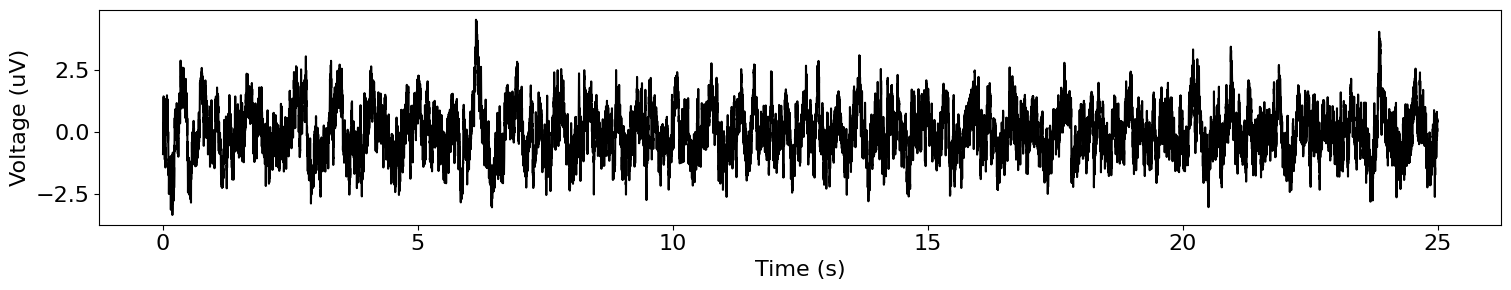

In [93]:
# Plot time series
plot_time_series(times, cz_signal_ap)

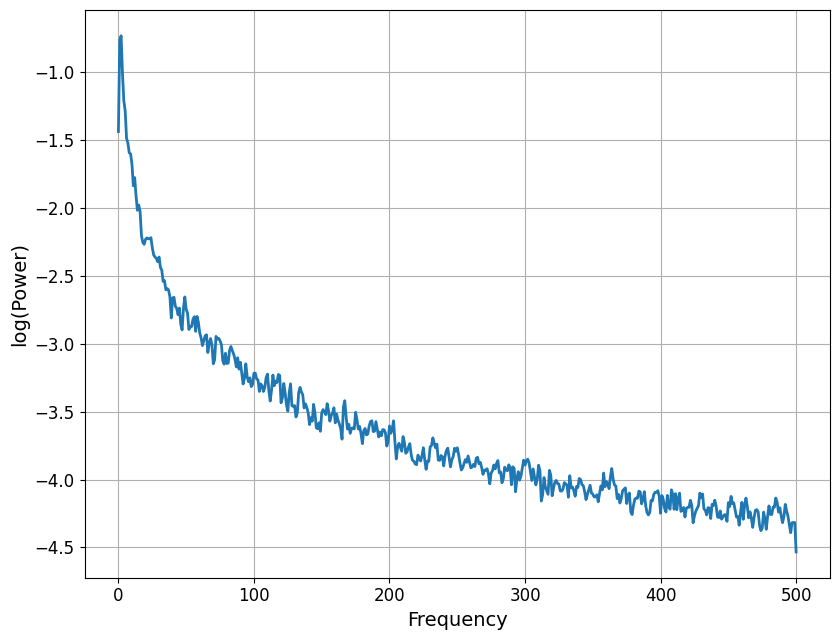

In [94]:
# Plot the simulated data, in the frequency domain
freqs, powers = compute_spectrum_welch(cz_signal_ap, s_rate, nperseg=s_rate, noverlap=s_rate//2)
plot_spectra(freqs, powers, log_powers=True)

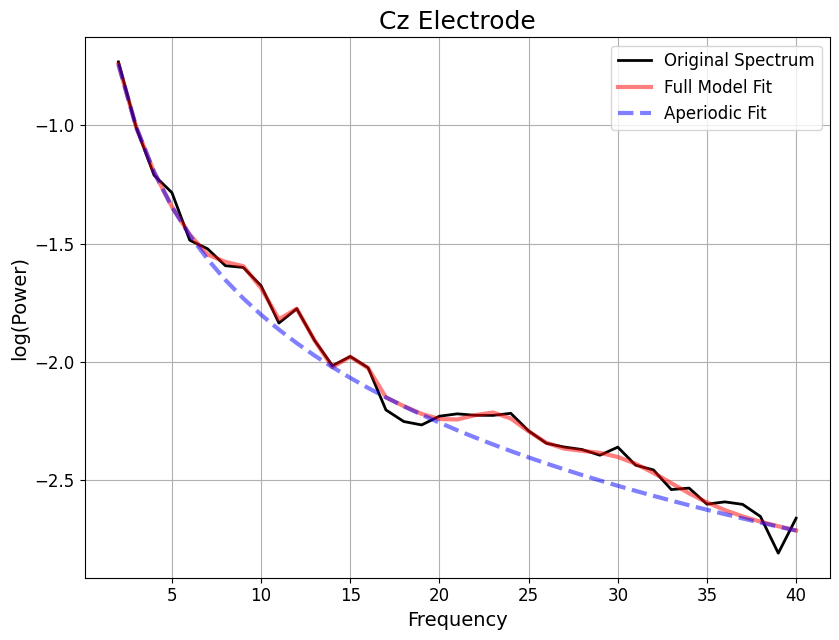

In [96]:
# Initialise Spectral Model
fm_cz = SpectralModel(min_peak_height=0.05, verbose=False)

# Set frequency range
freq_range = [2, 40]

# Fitting, plotting and reporting spectral models for each signal
fm_cz.fit(freqs, powers, freq_range)
fm_cz.plot(title = "Cz Electrode")

In [97]:
# Set seed for consistency
set_random_seed(36)

# Simulation settings
n_seconds = 25 # Number of seconds
s_rate = 1000 # Sampling rate
times = create_times(n_seconds, s_rate)

In [103]:
high_pass_filter = 1
low_pass_filter = 50
#aperiodic_signal = sim_powerlaw (n_seconds, s_rate, exponent = -1.5, f_range = [high_pass_filter, low_pass_filter])

components = {
    'sim_powerlaw': {'exponent': -1.5, 'f_range': [high_pass_filter, low_pass_filter]},
    'sim_oscillation': {'freq': 10}
}

cz_signal = sim_combined(n_seconds=n_seconds, fs=s_rate, components=components)                

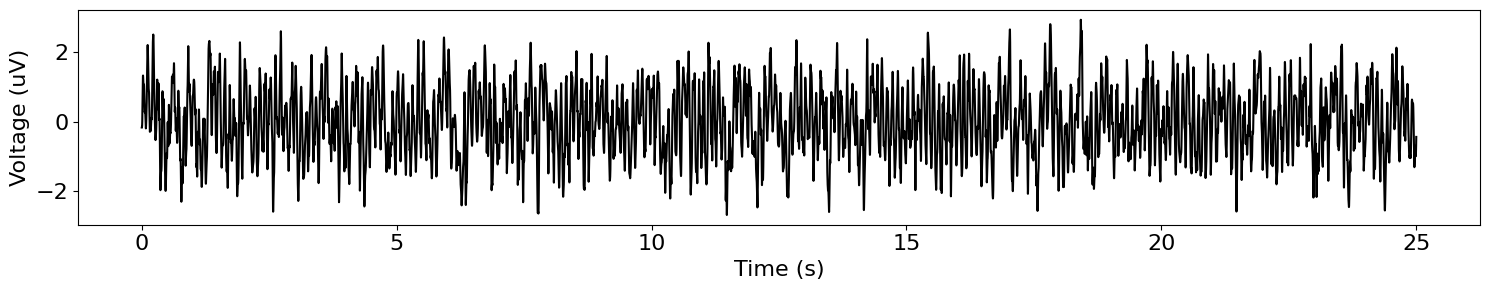

In [104]:
# Plot time series
plot_time_series(times, cz_signal)

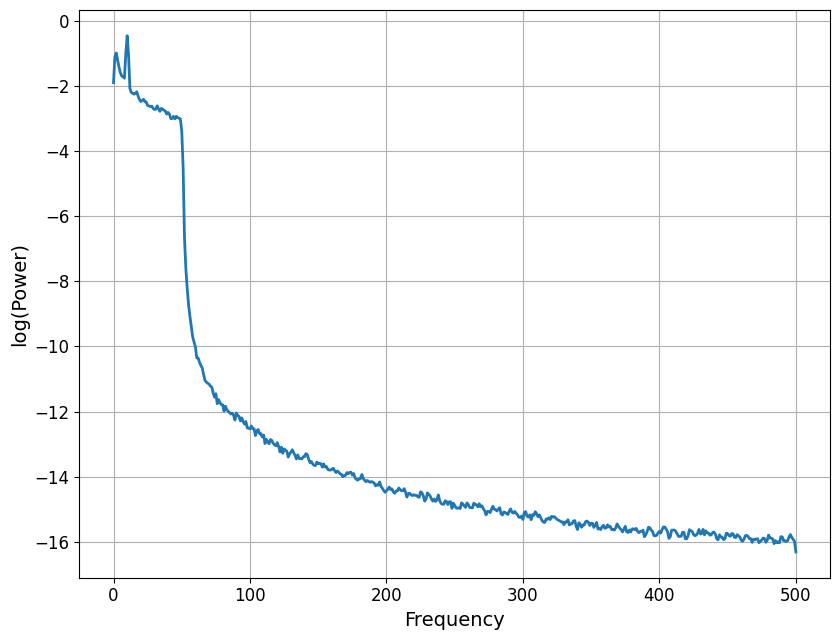

In [105]:
# Plot the simulated data, in the frequency domain
freqs, powers = compute_spectrum_welch(cz_signal, s_rate, nperseg=s_rate, noverlap=s_rate//2)
plot_spectra(freqs, powers, log_powers=True)

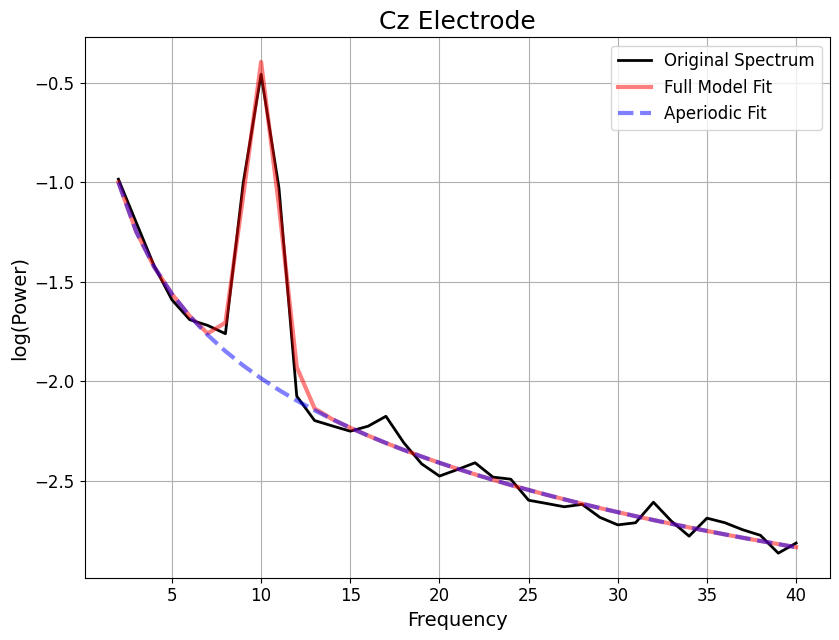

In [106]:
# Initialise Spectral Model
fm_cz = SpectralModel(min_peak_height=0.05, verbose=False)

# Set frequency range
freq_range = [2, 40]

# Fitting, plotting and reporting spectral models for each signal
fm_cz.fit(freqs, powers, freq_range)
fm_cz.plot(title = "Cz Electrode")